# Backpropagation From Scratch — Assignment Notebook

**Goal:** Implement every piece of backprop manually in NumPy — no autograd, no PyTorch.  
**Target roles:** Applied Scientist at Anthropic, Google, OpenAI, Meta, Amazon, Netflix  

### How to use this notebook
- Each section has **theory/derivations** (read these) and **`# YOUR CODE HERE`** blocks (implement these)
- Test cells follow each implementation — run them to verify your work
- Hints are provided but try without them first
- The cheat sheet at the end is for review AFTER you've implemented everything

### Architecture we're building
```
Input(2) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(1, Sigmoid) → BCE Loss
```

In [106]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

---
## Part 1: Synthetic Data (Provided — no need to implement)

We'll use a non-linearly separable 2D dataset so the network actually needs hidden layers.

X shape: (500, 2)
y shape: (500, 1)


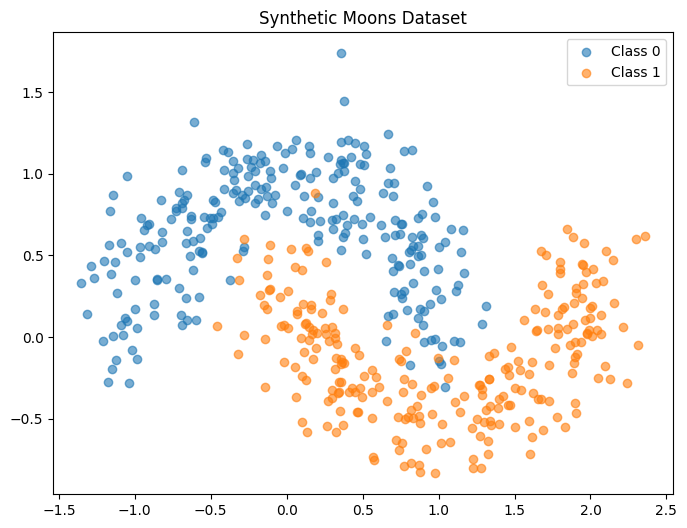

In [107]:
# PROVIDED — just run this cell
def make_moons(n_samples=500, noise=0.2):
    n = n_samples // 2
    theta_top = np.linspace(0, np.pi, n)
    theta_bot = np.linspace(0, np.pi, n)
    x_top = np.column_stack([np.cos(theta_top), np.sin(theta_top)])
    x_bot = np.column_stack([1 - np.cos(theta_bot), 1 - np.sin(theta_bot) - 0.5])
    X = np.vstack([x_top, x_bot])
    y = np.hstack([np.zeros(n), np.ones(n)])
    X += np.random.randn(*X.shape) * noise
    idx = np.random.permutation(n_samples)
    return X[idx], y[idx].reshape(-1, 1)

X, y = make_moons(500, noise=0.2)
print(f"X shape: {X.shape}")  # (500, 2)
print(f"y shape: {y.shape}")  # (500, 1)

plt.figure(figsize=(8, 6))
plt.scatter(X[y.ravel()==0, 0], X[y.ravel()==0, 1], label='Class 0', alpha=0.6)
plt.scatter(X[y.ravel()==1, 0], X[y.ravel()==1, 1], label='Class 1', alpha=0.6)
plt.legend()
plt.title('Synthetic Moons Dataset')
plt.show()

---
## Part 2: Weight Initialization

### Theory

**He Initialization (for ReLU):**
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}}}}\right)$$

The $\sqrt{2}$ compensates for ReLU killing ~half the activations, which halves the variance each layer.

**Xavier/Glorot Initialization (for sigmoid/tanh):**
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}} + n_{\text{out}}}}\right)$$

### Task
Implement `initialize_parameters` that creates W and b for each layer.

**Requirements:**
- `W_l` shape: `(n_in, n_out)` — we use this convention so forward pass is `X @ W + b`
- `b_l` shape: `(1, n_out)` — row vector for broadcasting across batch
- Biases always initialized to zero
- Support both 'he' and 'xavier' init types

In [108]:
def initialize_parameters(layer_dims, init_type='he'):
    """
    Initialize weights and biases for a network.
    
    Args:
        layer_dims: list of layer sizes, e.g. [2, 64, 32, 1]
        init_type: 'he' (for ReLU) or 'xavier' (for sigmoid/tanh)
    
    Returns:
        params: dict with W1, b1, W2, b2, ...
    """
    params = {}
    L = len(layer_dims)
    
    for l in range(1, L):
        n_in = layer_dims[l - 1]
        n_out = layer_dims[l]
        
        # YOUR CODE HERE
        if init_type == 'he':
            init_scale = np.sqrt(2/n_in)
        else:
            init_scale = np.sqrt(2 / (n_in + n_out))
        
        params[f'W{l}'] = np.random.randn(n_in, n_out) * init_scale  # replace
        params[f'b{l}'] = np.zeros((1,n_out))  # replace
    
    return params


# Test
layer_dims = [2, 64, 32, 1]
params = initialize_parameters(layer_dims, init_type='he')

In [109]:
# ---- TEST CELL: Weight Initialization ----
assert params['W1'].shape == (2, 64), f"W1 shape wrong: {params['W1'].shape}"
assert params['b1'].shape == (1, 64), f"b1 shape wrong: {params['b1'].shape}"
assert params['W2'].shape == (64, 32), f"W2 shape wrong: {params['W2'].shape}"
assert params['W3'].shape == (32, 1), f"W3 shape wrong: {params['W3'].shape}"
assert np.allclose(params['b1'], 0), "Biases should be zero"
assert np.allclose(params['b2'], 0), "Biases should be zero"

# Variance check for He init
w1_var = params['W1'].var()
expected_var = 2.0 / 2  # 2/n_in for He
assert abs(w1_var - expected_var) < 0.3, f"W1 variance {w1_var:.4f} too far from expected {expected_var:.4f}"

print("All init tests passed!")
print(f"W1 variance: {w1_var:.4f} (expected ~{expected_var:.4f})")
print(f"W2 variance: {params['W2'].var():.4f} (expected ~{2/64:.4f})")

All init tests passed!
W1 variance: 1.0138 (expected ~1.0000)
W2 variance: 0.0303 (expected ~0.0312)


---
## Part 3: Activation Functions — Forward AND Backward

Each activation needs both directions. This is where chain rule becomes concrete.

### Derivations

**ReLU:**
$$f(z) = \max(0, z) \qquad f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

**Sigmoid:**
$$\sigma(z) = \frac{1}{1 + e^{-z}} \qquad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$

Proof of sigmoid derivative (interview favorite):
$$\frac{d}{dz}\sigma(z) = \frac{e^{-z}}{(1 + e^{-z})^2} = \frac{1}{1 + e^{-z}} \cdot \frac{e^{-z}}{1 + e^{-z}} = \sigma(z)(1 - \sigma(z))$$

**Tanh:**
$$f(z) = \tanh(z) \qquad f'(z) = 1 - \tanh^2(z)$$

**Leaky ReLU:**
$$f(z) = \begin{cases} z & \text{if } z > 0 \\ \alpha z & \text{otherwise} \end{cases} \qquad f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ \alpha & \text{otherwise} \end{cases}$$

### Task
Implement forward and backward for each activation.

**Key concept for backward functions:**
- `dA` = upstream gradient (dL/dA) coming from the layer above
- `z` = pre-activation values saved during forward pass
- Return `dZ = dA * f'(z)` — this is the chain rule!

In [110]:
# ===================== RELU =====================

def relu_forward(z):
    """ReLU: max(0, z)"""
    # YOUR CODE HERE
    return np.maximum(0.0, z)

def relu_backward(dA, z):
    """
    ReLU backward.
    
    dA: upstream gradient (dL/dA)          shape: (batch, n_out)
    z:  pre-activation from forward pass   shape: (batch, n_out)
    
    Returns: dZ = dL/dZ = dA * (1 if z > 0 else 0)   shape: (batch, n_out)
    """
    # YOUR CODE HERE
    dZ = dA * np.where(z>0, 1.0, 0.0)  # element-wise: chain rule
    return dZ


# ===================== SIGMOID =====================

def sigmoid_forward(z):
    """Numerically stable sigmoid."""
    # YOUR CODE HERE
    # Hint: clip z to [-500, 500] first to prevent overflow in exp
    z = np.clip(z, -500, 500)
    return np.where(z>0, 1.0 / (1 + np.exp(-z)), np.exp(z)/ (np.exp(z) + 1))

def sigmoid_backward(dA, z):
    """
    Sigmoid backward: σ'(z) = σ(z)(1 - σ(z))
    
    Returns: dZ = dA * σ(z) * (1 - σ(z))
    """
    # YOUR CODE HERE
    dZ = dA * sigmoid_forward(z) * (1 - sigmoid_forward(z))
    return dZ


# ===================== TANH =====================

def tanh_forward(z):
    # YOUR CODE HERE
    return 2 * sigmoid_forward(2 * z) - 1

def tanh_backward(dA, z):
    """
    Tanh backward: 1 - tanh^2(z)
    """
    # YOUR CODE HERE
    return dA * (1 - tanh_forward(z)**2)


# ===================== LEAKY RELU =====================

def leaky_relu_forward(z, alpha=0.01):
    # YOUR CODE HERE
    return np.where(z>0, z, alpha*z)

def leaky_relu_backward(dA, z, alpha=0.01):
    # YOUR CODE HERE
    return (dA * np.where(z>0, 1.0, alpha))

In [111]:
# ---- TEST CELL: Activation Functions ----

def numerical_gradient(f, z, eps=1e-7):
    """Finite difference gradient check."""
    return (f(z + eps) - f(z - eps)) / (2 * eps)

z_test = np.array([[-2.0, -0.5, 0.5, 2.0]])

# Test ReLU forward
relu_out = relu_forward(z_test)
assert np.allclose(relu_out, [[0, 0, 0.5, 2.0]]), f"ReLU forward wrong: {relu_out}"

# Test ReLU backward (numerical check)
dA_ones = np.ones_like(z_test)
relu_grad = relu_backward(dA_ones, z_test)
relu_num = numerical_gradient(relu_forward, z_test)
assert np.max(np.abs(relu_grad - relu_num)) < 1e-5, "ReLU backward failed gradient check"

# Test Sigmoid forward
sig_out = sigmoid_forward(np.array([[0.0]]))
assert np.allclose(sig_out, 0.5), f"Sigmoid(0) should be 0.5, got {sig_out}"

# Test Sigmoid backward (numerical check)
sig_grad = sigmoid_backward(dA_ones, z_test)
sig_num = numerical_gradient(sigmoid_forward, z_test)
print(sig_grad, sig_num)
assert np.max(np.abs(sig_grad - sig_num)) < 1e-5, "Sigmoid backward failed gradient check"

# Test Tanh forward
tanh_out = tanh_forward(np.array([[0.0]]))
assert np.allclose(tanh_out, 0.0), f"Tanh(0) should be 0, got {tanh_out}"

# Test Tanh backward (numerical check with dA=1)
tanh_grad = tanh_backward(dA_ones, z_test)
tanh_num = numerical_gradient(tanh_forward, z_test)
assert np.max(np.abs(tanh_grad - tanh_num)) < 1e-5, "Tanh backward failed gradient check"

# Test Tanh backward with non-trivial dA (catches missing dA * bug)
dA_test = np.array([[0.5, -1.0, 2.0, -0.3]])
tanh_grad_da = tanh_backward(dA_test, z_test)
expected_tanh_da = dA_test * (1 - tanh_forward(z_test)**2)
assert np.allclose(tanh_grad_da, expected_tanh_da), "Tanh backward chain rule failed — dA not applied"

# Test Leaky ReLU
lrelu_out = leaky_relu_forward(np.array([[-1.0, 1.0]]))
assert np.allclose(lrelu_out, [[-0.01, 1.0]]), f"Leaky ReLU forward wrong: {lrelu_out}"

print("All activation tests passed!")
print(f"  Sigmoid gradient check max error: {np.max(np.abs(sig_grad - sig_num)):.2e}")
print(f"  ReLU gradient check max error:    {np.max(np.abs(relu_grad - relu_num)):.2e}")
print(f"  Tanh gradient check max error:    {np.max(np.abs(tanh_grad - tanh_num)):.2e}")
print(f"  Tanh dA chain rule check:         {np.max(np.abs(tanh_grad_da - expected_tanh_da)):.2e}")

[[0.10499359 0.23500371 0.23500371 0.10499359]] [[0.10499359 0.23500371 0.23500371 0.10499358]]
All activation tests passed!
  Sigmoid gradient check max error: 4.66e-10
  ReLU gradient check max error:    5.26e-10
  Tanh gradient check max error:    1.88e-09
  Tanh dA chain rule check:         0.00e+00


---
## Part 4: Loss Functions — Forward AND Backward

### Binary Cross-Entropy (BCE)
$$L = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

### BCE Gradient w.r.t. predictions
$$\frac{\partial L}{\partial \hat{y}_i} = \frac{1}{N} \cdot \frac{\hat{y}_i - y_i}{\hat{y}_i(1 - \hat{y}_i)}$$

### The Beautiful Simplification: BCE + Sigmoid Combined

When you chain BCE gradient with sigmoid derivative:

$$\frac{\partial L}{\partial z} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})} \cdot \hat{y}(1 - \hat{y}) = \frac{1}{N}(\hat{y} - y)$$

The $\hat{y}(1 - \hat{y})$ cancels! This is why we pair sigmoid with BCE.

### Task
Implement three functions:
1. BCE forward (the loss value)
2. BCE backward (gradient w.r.t. sigmoid output)
3. Combined BCE + Sigmoid backward (the shortcut)

In [112]:
def binary_cross_entropy_forward(y_pred, y_true):
    """
    Binary cross-entropy loss.
    
    y_pred: sigmoid output   shape: (batch, 1)
    y_true: binary labels    shape: (batch, 1)
    
    Returns: scalar loss
    """
    # YOUR CODE HERE
    # Hint: clip y_pred to [eps, 1-eps] where eps=1e-8 to avoid log(0)
    y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1-y_pred))


def binary_cross_entropy_backward(y_pred, y_true):
    """
    BCE gradient w.r.t. y_pred (sigmoid output).
    
    Returns: dL/d(y_pred)    shape: (batch, 1)
    """
    # YOUR CODE HERE
    N = y_pred.shape[0]
    return (1/N) * (y_pred - y_true) / (y_pred * (1 - y_pred))


def bce_sigmoid_combined_backward(y_pred, y_true):
    """
    Combined BCE + Sigmoid gradient (the elegant shortcut).
    This goes directly from loss to pre-activation gradient.
    
    Returns: dL/dZ    shape: (batch, 1)
    """
    # YOUR CODE HERE
    N = y_pred.shape[0]
    return (y_pred - y_true) / N

In [113]:
# ---- TEST CELL: Loss Functions ----

y_pred_test = sigmoid_forward(np.array([[0.8], [-0.5], [1.2]]))
y_true_test = np.array([[1.0], [0.0], [1.0]])

# Test forward
loss = binary_cross_entropy_forward(y_pred_test, y_true_test)
assert loss > 0, "Loss should be positive"
assert isinstance(loss, (float, np.floating)), "Loss should be scalar"
print(f"BCE Loss: {loss:.4f}")

# Test: separate vs combined should give same result
z_test_loss = np.array([[0.8], [-0.5], [1.2]])
dA = binary_cross_entropy_backward(y_pred_test, y_true_test)
dZ_separate = sigmoid_backward(dA, z_test_loss)
dZ_combined = bce_sigmoid_combined_backward(y_pred_test, y_true_test)

assert np.max(np.abs(dZ_separate - dZ_combined)) < 1e-6, \
    f"Separate and combined gradients don't match!\nSeparate: {dZ_separate.ravel()}\nCombined: {dZ_combined.ravel()}"

print(f"Separate gradient: {dZ_separate.ravel()}")
print(f"Combined gradient: {dZ_combined.ravel()}")
print(f"Max difference:    {np.max(np.abs(dZ_separate - dZ_combined)):.2e}")
print("\nLoss tests passed! The cancellation works.")

BCE Loss: 0.3695
Separate gradient: [-0.10334184  0.12584689 -0.07715841]
Combined gradient: [-0.10334184  0.12584689 -0.07715841]
Max difference:    1.39e-17

Loss tests passed! The cancellation works.


---
## Part 5: Forward Pass — Full Network

For each layer $l$:
$$Z^{[l]} = A^{[l-1]} W^{[l]} + b^{[l]}$$
$$A^{[l]} = g^{[l]}(Z^{[l]})$$

**Critical:** Cache $Z^{[l]}$ and $A^{[l]}$ at each layer — you need them for backprop.

### Dimension flow
```
A0: (batch, 2)                          <- input
Z1: (batch, 2) @ (2, 64) + (1, 64)     = (batch, 64)
A1: relu(Z1)                            = (batch, 64)
Z2: (batch, 64) @ (64, 32) + (1, 32)   = (batch, 32)
A2: relu(Z2)                            = (batch, 32)
Z3: (batch, 32) @ (32, 1) + (1, 1)     = (batch, 1)
A3: sigmoid(Z3)                         = (batch, 1)  <- output
```

In [114]:
def forward_pass(X, params, activations):
    """
    Full forward pass through the network.
    
    Args:
        X: input data             shape: (batch, n_features)
        params: dict with W1, b1, W2, b2, ...
        activations: list of activation names, e.g. ['relu', 'relu', 'sigmoid']
    
    Returns:
        output: final predictions  shape: (batch, n_out)
        cache: dict with A0, Z1, A1, Z2, A2, ... (needed for backprop)
    """
    cache = {'A0': X}
    L = len(activations)
    A = X
    
    for l in range(1, L + 1):
        # YOUR CODE HERE
        W = params[f'W{l}']
        b = params[f'b{l}']
        Z = A @ W + b
        cache[f'Z{l}'] = Z

        # apply activation
        activation_name = activations[l-1]
        if activation_name == 'relu':
            # apply relu
            A = relu_forward(Z)
        elif activation_name == 'sigmoid':
            A = sigmoid_forward(Z)
        else:
            raise ValueError(f"Activation Function not used: {activation_name}")
        cache[f'A{l}'] = A
    
    return A, cache

In [115]:
# ---- TEST CELL: Forward Pass ----

activations = ['relu', 'relu', 'sigmoid']
y_pred, cache = forward_pass(X, params, activations)

assert y_pred.shape == (500, 1), f"Output shape wrong: {y_pred.shape}"
assert cache['Z1'].shape == (500, 64), f"Z1 shape wrong: {cache['Z1'].shape}"
assert cache['A1'].shape == (500, 64), f"A1 shape wrong: {cache['A1'].shape}"
assert cache['Z2'].shape == (500, 32), f"Z2 shape wrong: {cache['Z2'].shape}"
assert cache['A2'].shape == (500, 32), f"A2 shape wrong: {cache['A2'].shape}"
assert cache['Z3'].shape == (500, 1), f"Z3 shape wrong: {cache['Z3'].shape}"
assert 'A0' in cache, "Cache must include A0 (input)"
assert np.all(y_pred >= 0) and np.all(y_pred <= 1), "Output should be in [0, 1] (sigmoid)"

loss = binary_cross_entropy_forward(y_pred, y)
print(f"Forward pass shapes all correct!")
print(f"Output range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
print(f"Initial loss: {loss:.4f}")

Forward pass shapes all correct!
Output range: [0.2047, 0.9322]
Initial loss: 0.6442


---
## Part 6: Backward Pass — THE CORE

This is the heart of the notebook. For each layer $l$ going backward:

### The three gradients per layer

Given $dA^{[l]}$ (upstream gradient arriving at this layer's output):

**Step 1: Through activation -> get dZ**
$$dZ^{[l]} = dA^{[l]} \odot g'^{[l]}(Z^{[l]})$$

**Step 2: Parameter gradients**
$$dW^{[l]} = (A^{[l-1]})^T \cdot dZ^{[l]}$$
$$db^{[l]} = \sum_{\text{batch}} dZ^{[l]}$$

**Step 3: Pass gradient to previous layer**
$$dA^{[l-1]} = dZ^{[l]} \cdot (W^{[l]})^T$$

### Dimension checks (memorize!)

| Quantity | Shape | Must match |
|----------|-------|------------|
| $dZ^{[l]}$ | (batch, $n_l$) | same as $Z^{[l]}$ |
| $dW^{[l]}$ | ($n_{l-1}$, $n_l$) | same as $W^{[l]}$ |
| $db^{[l]}$ | (1, $n_l$) | same as $b^{[l]}$ |
| $dA^{[l-1]}$ | (batch, $n_{l-1}$) | same as $A^{[l-1]}$ |

### Special case: last layer
Use `bce_sigmoid_combined_backward` to go directly from loss to $dZ^{[L]}$, skipping the separate BCE backward + sigmoid backward (numerically more stable).

In [116]:
def _activation_backward(dA, Z, activation_name):
    """Helper: dispatch to the right activation backward function."""
    if activation_name == 'relu':
        return relu_backward(dA, Z)
    elif activation_name == 'sigmoid':
        return sigmoid_backward(dA, Z)
    elif activation_name == 'tanh':
        return tanh_backward(dA, Z)
    elif activation_name == 'leaky_relu':
        return leaky_relu_backward(dA, Z)
    else:
        raise ValueError(f"Unknown activation: {activation_name}")


def backward_pass(y_pred, y_true, params, cache, activations):
    """
    Full backward pass — computes all gradients.
    
    Args:
        y_pred: network output          shape: (batch, 1)
        y_true: ground truth labels     shape: (batch, 1)
        params: network weights
        cache: saved values from forward pass (A0, Z1, A1, Z2, A2, ...)
        activations: list of activation names
    
    Returns:
        grads: dict with dW1, db1, dW2, db2, ...
    """
    grads = {}
    L = len(activations)
    
    # ---- LAST LAYER: use combined BCE+sigmoid shortcut ----
    # YOUR CODE HERE
    grads[f'dZ{L}'] = bce_sigmoid_combined_backward(y_pred, y_true) #(500,1)
    grads[f'dW{L}'] = cache[f'A{L-1}'].T @ grads[f'dZ{L}'] #(32,1)
    grads[f'db{L}'] = np.sum(grads[f'dZ{L}'], axis=0, keepdims=True) #(1,1)
    
    
    # ---- REMAINING LAYERS: loop backward from L-1 to 1 ----
    for l in range(L - 1, 0, -1):
        # YOUR CODE HERE
        grads[f'dA{l}'] = grads[f'dZ{l+1}'] @ params[f'W{l+1}'].T # (500,32); (500,64)
        grads[f'dZ{l}'] = _activation_backward(grads[f'dA{l}'], cache[f'Z{l}'], activations[l-1]) #(500,32); (500,64)
        grads[f'dW{l}'] = cache[f'A{l-1}'].T @ grads[f'dZ{l}'] #(64,32); (2,64)
        grads[f'db{l}'] = np.sum(grads[f'dZ{l}'], axis=0, keepdims=True) #(1,32); (1,64)
    
    return grads

In [117]:
# ---- TEST CELL: Backward Pass Shape Check ----

grads = backward_pass(y_pred, y, params, cache, activations)

for l in range(1, len(layer_dims)):
    assert grads[f'dW{l}'].shape == params[f'W{l}'].shape, \
        f"dW{l} shape {grads[f'dW{l}'].shape} != W{l} shape {params[f'W{l}'].shape}"
    assert grads[f'db{l}'].shape == params[f'b{l}'].shape, \
        f"db{l} shape {grads[f'db{l}'].shape} != b{l} shape {params[f'b{l}'].shape}"

print("All backward pass shape checks passed!")
for l in range(1, len(layer_dims)):
    print(f"  dW{l}: {grads[f'dW{l}'].shape}  db{l}: {grads[f'db{l}'].shape}")

All backward pass shape checks passed!
  dW1: (2, 64)  db1: (1, 64)
  dW2: (64, 32)  db2: (1, 32)
  dW3: (32, 1)  db3: (1, 1)


---
## Part 7: Numerical Gradient Checking

**Critical interview skill.** Verify your backprop with finite differences:

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta + \epsilon) - L(\theta - \epsilon)}{2\epsilon}$$

If relative error between analytic and numerical gradients is < $10^{-5}$, your implementation is correct.

### Task
Implement gradient checking that perturbs each parameter and compares with your analytic gradients.

In [118]:
def gradient_check(X, y, params, activations, eps=1e-7):
    """
    Numerical gradient checking.
    
    For each parameter:
    1. Perturb it by +eps and -eps
    2. Compute loss at both
    3. Numerical gradient = (loss_plus - loss_minus) / (2 * eps)
    4. Compare with analytic gradient
    """
    # Get analytic gradients
    y_pred, cache = forward_pass(X, params, activations)
    grads = backward_pass(y_pred, y, params, cache, activations)
    
    print("Gradient Check Results:")
    print("=" * 60)
    
    all_passed = True
    for param_name in sorted(params.keys()):
        param = params[param_name]
        grad_analytic = grads[f'd{param_name}']
        
        # Check a few random elements for speed
        n_checks = min(5, param.size)
        indices = np.random.choice(param.size, n_checks, replace=False)
        
        max_rel_error = 0
        for idx in indices:
            multi_idx = np.unravel_index(idx, param.shape)
            
            # YOUR CODE HERE           
             # 1. Save old value: old_val = param[multi_idx]
            old_val = param[multi_idx]

             # 2. Set param[multi_idx] = old_val + eps, forward pass, get loss_plus
            param[multi_idx] = old_val + eps
            params[param_name] = param
            y_pred, cache_plus = forward_pass(X, params, activations)
            loss_plus = binary_cross_entropy_forward(y_pred, y)

            # 3. Set param[multi_idx] = old_val - eps, forward pass, get loss_minus
            param[multi_idx] = old_val - eps
            params[param_name] = param
            y_pred, cache_minus = forward_pass(X, params, activations)
            loss_minus = binary_cross_entropy_forward(y_pred, y)

            # 4. Restore: param[multi_idx] = old_val
            param[multi_idx] = old_val
            params[param_name] = param

            # 5. grad_num = (loss_plus - loss_minus) / (2 * eps)
            grad_num = (loss_plus - loss_minus) / (2 * eps)

            grad_ana = grad_analytic[multi_idx]

            # 6. Compute relative error
            rel_error = abs(grad_num - grad_ana) / (abs(grad_num) + abs(grad_ana) + 1e-8)
            max_rel_error = max(max_rel_error, rel_error)
        
        status = "PASS" if max_rel_error < 1e-5 else "FAIL"
        if status == "FAIL": all_passed = False
        print(f"  {param_name:4s}: max relative error = {max_rel_error:.2e}  {status}")
    
    return all_passed


# Run on small batch for speed
X_small, y_small = X[:20], y[:20]
passed = gradient_check(X_small, y_small, params, activations)
print(f"\nOverall: {'ALL PASSED' if passed else 'SOME FAILED - check your backward pass'}")

Gradient Check Results:
  W1  : max relative error = 3.85e-07  PASS
  W2  : max relative error = 1.51e-07  PASS
  W3  : max relative error = 1.28e-08  PASS
  b1  : max relative error = 4.72e-08  PASS
  b2  : max relative error = 2.71e-08  PASS
  b3  : max relative error = 4.34e-09  PASS

Overall: ALL PASSED


---
## Part 8: Optimizers — SGD and Adam

### SGD
$$\theta = \theta - \alpha \nabla\theta$$

### Adam
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat{m}_t = m_t / (1 - \beta_1^t) \qquad \hat{v}_t = v_t / (1 - \beta_2^t)$$
$$\theta = \theta - \alpha \cdot \hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon)$$

You've implemented these before — do it again from memory this time.

In [119]:
def sgd_update(params, grads, lr=0.01):
    """
    Vanilla SGD: theta = theta - lr * grad
    """
    for key in params:
        g = grads[f'd{key}']
        params[key] -= lr * g
    
    return params


class AdamOptimizer:
    """
    Adam optimizer with bias correction.
    """
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        
        # YOUR CODE HERE
        # Initialize first moment (m) and second moment (v) as zeros
        # matching each parameter's shape
        self.m = {f'd{key}': np.zeros_like(val) for key, val in params.items()} # replace
        self.v = {f'd{key}': np.zeros_like(val) for key, val in params.items()}  # replace
    
    def update(self, params, grads):
        self.t += 1
        
        for key in params:
            g = grads[f'd{key}']
            
            # YOUR CODE HERE
            self.m[f'd{key}'] = self.beta1 * self.m[f'd{key}'] + (1- self.beta1) * g
            self.v[f'd{key}'] = self.beta2 * self.v[f'd{key}'] + (1- self.beta2) * g**2

            m_hat = self.m[f'd{key}'] / (1 - self.beta1**self.t)
            v_hat = self.v[f'd{key}'] / (1 - self.beta2**self.t)
            params[key] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        
        return params

In [120]:
# ---- TEST CELL: Optimizers ----

import copy

# Test SGD
params_copy = copy.deepcopy(params)
grads_test = backward_pass(y_pred, y, params_copy, cache, activations)
w1_before = params_copy['W1'].copy()
sgd_update(params_copy, grads_test, lr=0.1)
assert not np.allclose(params_copy['W1'], w1_before), "SGD didn't update weights!"
print("SGD test passed!")

# Test Adam
params_copy2 = copy.deepcopy(params)
adam = AdamOptimizer(params_copy2, lr=0.001)
w1_before2 = params_copy2['W1'].copy()
grads_test2 = backward_pass(y_pred, y, params_copy2, cache, activations)
adam.update(params_copy2, grads_test2)
assert not np.allclose(params_copy2['W1'], w1_before2), "Adam didn't update weights!"
assert adam.t == 1, "Adam timestep should be 1 after one update"
print("Adam test passed!")

SGD test passed!
Adam test passed!


---
## Part 9: Training Loop

### Task
Write the full training loop with mini-batches:
1. Shuffle data each epoch
2. For each mini-batch: forward -> loss -> backward -> update
3. Track loss and accuracy per epoch

In [121]:
def compute_accuracy(y_pred, y_true, threshold=0.5):
    """Provided."""
    predictions = (y_pred >= threshold).astype(float)
    return np.mean(predictions == y_true)


def train(X, y, layer_dims, activations, optimizer='adam', lr=0.001, 
          epochs=200, batch_size=32, print_every=20):
    """
    Full training loop with mini-batches.
    """
    N = X.shape[0]
    params = initialize_parameters(layer_dims, init_type='he')
    
    if optimizer == 'adam':
        opt = AdamOptimizer(params, lr=lr)
    
    history = {'loss': [], 'accuracy': []}
    
    for epoch in range(epochs):
        # YOUR CODE HERE
        # 1. Shuffle data (np.random.permutation)
        indices = np.random.permutation(N)
        X_shuffled, y_shuffled = X[indices], y[indices]
        # 2. Loop over mini-batches:
        for i in range(0, N, batch_size):
            #a. Slice X_batch, y_batch
            X_batch, y_batch = X_shuffled[i:i+batch_size], y_shuffled[i:i+batch_size]
            #b. forward_pass on batch
            y_pred, cache = forward_pass(X_batch,params,activations)
            #c. backward_pass
            grads = backward_pass(y_pred,y_batch,params,cache,activations)
            #d. update params (opt.update for adam, sgd_update for sgd)
            if optimizer == 'adam':
                params = opt.update(params,grads)
            else:
                #sgd
                params = sgd_update(params,grads,lr)


        # 3. compute full-dataset loss and accuracy
        y_pred_all, _ = forward_pass(X,params,activations)
        full_loss = binary_cross_entropy_forward(y_pred_all,y)
        acc_full = compute_accuracy(y_pred_all, y)

        if epoch % print_every == 0:
            print(f"Epoch {epoch:4d}: loss = {full_loss:4f}, acc = {acc_full:4f}")

        # 4. Append to history, print periodically
        history['loss'].append(full_loss)
        history['accuracy'].append(acc_full)
    
    return params, history


# Train
print("Training with Adam:")
print("=" * 50)
trained_params, history = train(
    X, y, 
    layer_dims=[2, 64, 32, 1], 
    activations=['relu', 'relu', 'sigmoid'],
    optimizer='adam', lr=0.001, epochs=200, batch_size=32
)

Training with Adam:
Epoch    0: loss = 0.373174, acc = 0.830000
Epoch   20: loss = 0.210259, acc = 0.912000
Epoch   40: loss = 0.129753, acc = 0.948000
Epoch   60: loss = 0.079517, acc = 0.974000
Epoch   80: loss = 0.067386, acc = 0.974000
Epoch  100: loss = 0.062864, acc = 0.978000
Epoch  120: loss = 0.059690, acc = 0.980000
Epoch  140: loss = 0.056875, acc = 0.980000
Epoch  160: loss = 0.055051, acc = 0.976000
Epoch  180: loss = 0.053964, acc = 0.974000


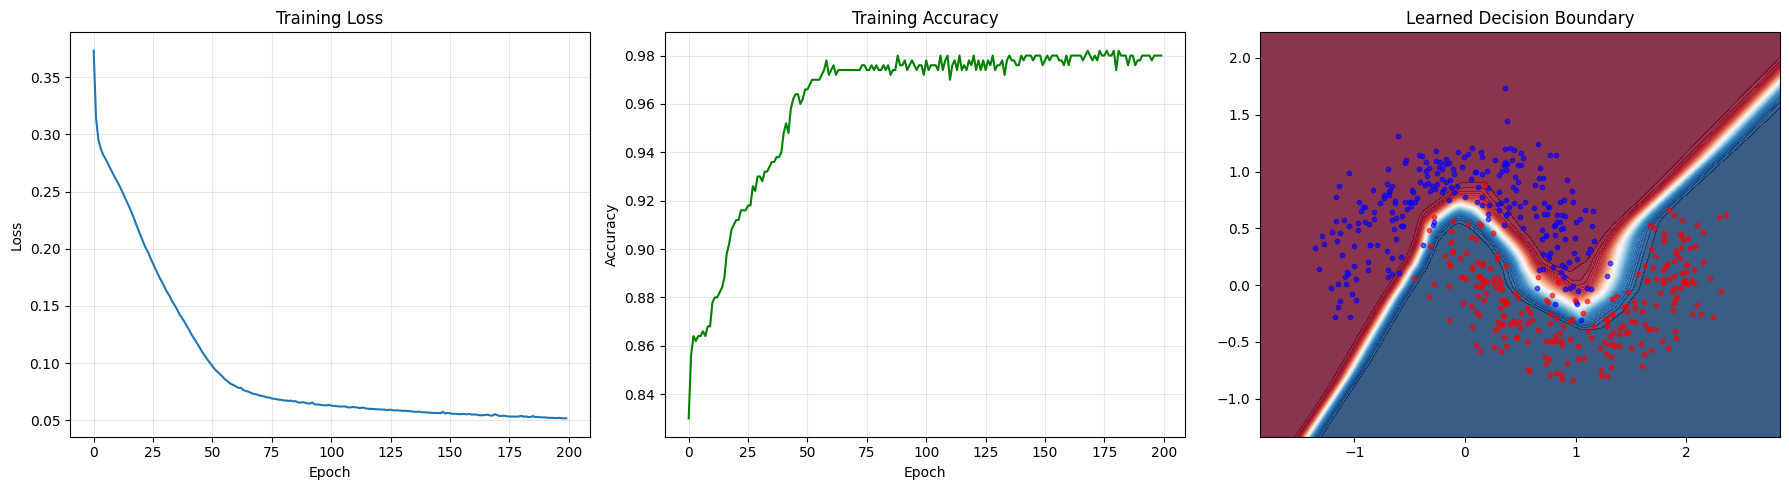

In [122]:
# ---- VISUALIZATION (provided — run after training works) ----

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['loss'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['accuracy'], color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy'); axes[1].grid(True, alpha=0.3)

# Decision boundary
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_input = np.column_stack([xx.ravel(), yy.ravel()])
Z_grid, _ = forward_pass(grid_input, trained_params, ['relu', 'relu', 'sigmoid'])
Z_grid = Z_grid.reshape(xx.shape)
axes[2].contourf(xx, yy, Z_grid, levels=50, cmap='RdBu', alpha=0.8)
axes[2].scatter(X[y.ravel()==0, 0], X[y.ravel()==0, 1], c='blue', s=10, alpha=0.6)
axes[2].scatter(X[y.ravel()==1, 0], X[y.ravel()==1, 1], c='red', s=10, alpha=0.6)
axes[2].set_title('Learned Decision Boundary')
plt.tight_layout()
plt.show()

---
## Part 10: Softmax + Cross-Entropy (Multi-class)

Binary was sigmoid + BCE. Multi-class is softmax + CE.

### Softmax
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

**Numerical trick:** Subtract max(z) before exp to prevent overflow.

### Cross-Entropy Loss
$$L = -\frac{1}{N}\sum_{i=1}^{N} \sum_{c=1}^{C} y_{ic} \log(\hat{y}_{ic})$$

### Combined gradient (same magic as sigmoid + BCE)
$$\frac{\partial L}{\partial z_i} = \frac{1}{N}(\hat{y}_i - y_i)$$

In [123]:
def softmax_forward(z):
    """
    Numerically stable softmax.
    
    z: logits   shape: (batch, n_classes)
    Returns:     shape: (batch, n_classes)
    """
    # YOUR CODE HERE
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    return np.exp(z_shifted) / np.sum(np.exp(z_shifted), axis=1, keepdims=True)


def cross_entropy_forward(y_pred, y_true_onehot):
    """
    Multi-class cross-entropy loss.
    
    y_pred: softmax output       shape: (batch, n_classes)
    y_true_onehot: one-hot       shape: (batch, n_classes)
    """
    # YOUR CODE HERE
    return -np.mean(np.sum(y_true_onehot * np.log(y_pred + 1e-8), axis=1))


def softmax_cross_entropy_backward(y_pred, y_true_onehot):
    """
    Combined softmax + CE backward: dL/dZ = (1/N)(y_pred - y_true)
    """
    # YOUR CODE HERE
    return (1 / y_pred.shape[0]) * (y_pred - y_true_onehot)

In [124]:
# ---- TEST CELL: Softmax + Cross-Entropy ----

logits = np.array([[2.0, 1.0, 0.1], [0.5, 2.5, 0.3]])
y_onehot = np.array([[1, 0, 0], [0, 1, 0]])

probs = softmax_forward(logits)
# Softmax probabilities should sum to 1
assert np.allclose(probs.sum(axis=1), 1.0), f"Softmax rows don't sum to 1: {probs.sum(axis=1)}"
assert np.all(probs > 0), "Softmax outputs should all be positive"

loss_ce = cross_entropy_forward(probs, y_onehot)
assert loss_ce > 0, "CE loss should be positive"

grad_ce = softmax_cross_entropy_backward(probs, y_onehot)
assert grad_ce.shape == logits.shape, f"Gradient shape wrong: {grad_ce.shape}"

# Verify gradient = (1/N)(softmax - onehot)
expected_grad = (1.0 / 2) * (probs - y_onehot)
assert np.allclose(grad_ce, expected_grad), "Combined gradient doesn't match expected"

print("Softmax + CE tests passed!")
print(f"Probs: {probs}")
print(f"Loss:  {loss_ce:.4f}")

Softmax + CE tests passed!
Probs: [[0.65900114 0.24243297 0.09856589]
 [0.10860373 0.80247906 0.08891721]]
Loss:  0.3185


---
## Part 11: Batch Normalization Forward and Backward

**Interview frequency: HIGH.** This is one of the trickiest backward passes to derive.

### Forward (training)
$$\mu_B = \frac{1}{N}\sum x_i \qquad \sigma_B^2 = \frac{1}{N}\sum(x_i - \mu_B)^2$$
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$
$$y_i = \gamma \hat{x}_i + \beta$$

### Forward (inference)
Use running mean/var instead of batch stats. Running stats are computed as an exponential moving average during training:

$$\mu_{\text{running}} = m \cdot \mu_{\text{running}} + (1 - m) \cdot \mu_B$$
$$\sigma^2_{\text{running}} = m \cdot \sigma^2_{\text{running}} + (1 - m) \cdot \sigma^2_B$$

where $m$ is the momentum (typically 0.9 or 0.99). At inference, normalize using these running stats instead of batch stats. Gamma and beta are always used.

### Backward
- $d\gamma = \sum(dout \cdot \hat{x})$
- $d\beta = \sum(dout)$
- $dx = \frac{1}{N} \cdot \frac{1}{\sqrt{\sigma^2+\epsilon}} \left( N \cdot d\hat{x} - \sum d\hat{x} - \hat{x} \sum(d\hat{x} \cdot \hat{x}) \right)$

where $d\hat{x} = dout \cdot \gamma$

In [125]:
class BatchNorm:
    def __init__(self, n_features, momentum=0.9, eps=1e-5):
        self.gamma = np.ones((1, n_features))
        self.beta = np.zeros((1, n_features))
        self.eps = eps
        self.momentum = momentum
        self.running_mean = np.zeros((1, n_features))
        self.running_var = np.ones((1, n_features))
        self.cache = None
    
    def forward(self, x, training=True):
        """
        x: (batch, n_features)
        
        Training: use batch mean/var, update running stats
        Inference: use running mean/var
        """
        # YOUR CODE HERE
        # Training:
        if training:
            mu = np.mean(x, axis=0, keepdims=True)
            var = np.var(x, axis=0, keepdims=True)

            #  x_hat = (x - mu) / sqrt(var + eps)
            x_hat = (x - mu) / np.sqrt(var + self.eps)

            #  out = gamma * x_hat + beta
            out = self.gamma * x_hat + self.beta

            #  running_mean = momentum * running_mean + (1-momentum) * mu
            self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * mu

            #  running_var = momentum * running_var + (1-momentum) * var
            self.running_var = self.momentum * self.running_var + (1-self.momentum) * var

            #  Cache (x, x_hat, mu, var) for backward
            self.cache = (x, x_hat, mu, var)

        else:
            # Inference:
            #   Use running_mean/var instead of batch stats
            x_hat = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)
            out = self.gamma * x_hat + self.beta
        return out
        
        
    def backward(self, dout):
        """
        dout: upstream gradient   shape: (batch, n_features)
        Returns: dx, dgamma, dbeta
        """
        # YOUR CODE HERE
        x, x_hat, mu, var = self.cache
        N = x.shape[0]

        # dgamma = sum(dout * x_hat, axis=0, keepdims=True); sum across batch
        dgamma = np.sum(dout * x_hat,axis=0, keepdims=True) 

        # dbeta = sum(dout, axis=0, keepdims=True)
        dbeta = np.sum(dout, axis=0, keepdims=True)

        # dx_hat = dout * self.gamma
        dx_hat = dout * self.gamma

        # dx = (1/N) * std_inv * (N*dx_hat - sum(dx_hat) - x_hat*sum(dx_hat*x_hat))
        term1 = dx_hat  / (np.sqrt(var + self.eps))
        term2 = -np.sum(dx_hat, axis=0, keepdims=True) / (N * np.sqrt(var+self.eps))
        term3 = - x_hat * np.sum(dx_hat * x_hat, axis=0, keepdims=True)/ (N * np.sqrt(var + self.eps))
        dx = term1 + term2 +term3

        return dx, dgamma, dbeta

In [126]:
# ---- TEST CELL: BatchNorm ----

bn = BatchNorm(n_features=4)
x_test_bn = np.random.randn(8, 4) * 5 + 3  # non-zero mean, large variance

out_bn = bn.forward(x_test_bn, training=True)

# After BatchNorm, output should have ~zero mean and ~unit std
out_mean = out_bn.mean(axis=0)
out_std = out_bn.std(axis=0)
assert np.allclose(out_mean, 0, atol=1e-6), f"Output mean should be ~0, got {out_mean}"
assert np.allclose(out_std, 1, atol=0.2), f"Output std should be ~1, got {out_std}"

# Test backward shapes
dout_test = np.random.randn(8, 4)
dx, dgamma, dbeta = bn.backward(dout_test)
assert dx.shape == x_test_bn.shape, f"dx shape wrong: {dx.shape}"
assert dgamma.shape == (1, 4), f"dgamma shape wrong: {dgamma.shape}"
assert dbeta.shape == (1, 4), f"dbeta shape wrong: {dbeta.shape}"

print("BatchNorm tests passed!")
print(f"Input  mean: {x_test_bn.mean(axis=0).round(2)}, std: {x_test_bn.std(axis=0).round(2)}")
print(f"Output mean: {out_mean.round(4)}, std: {out_std.round(4)}")

BatchNorm tests passed!
Input  mean: [2.81 2.63 0.86 0.95], std: [6.57 4.91 2.51 2.69]
Output mean: [0. 0. 0. 0.], std: [1. 1. 1. 1.]


---
## Part 12: L2 Regularization in Backprop

### Modified loss
$$L_{\text{reg}} = L + \frac{\lambda}{2N} \sum_l \|W^{[l]}\|_F^2$$

### Modified gradient (only for weights, NOT biases)
$$\frac{\partial L_{\text{reg}}}{\partial W^{[l]}} = \frac{\partial L}{\partial W^{[l]}} + \frac{\lambda}{N} W^{[l]}$$

In [127]:
def compute_l2_penalty(params, lam, N):
    """L2 regularization penalty — only weights, not biases."""
    # YOUR CODE HERE
    # Sum of squared values for all W params, scaled by lam/(2N)
    penalty = 0

    for key, val in params.items():
        if key.startswith('W'):
            penalty += np.sum(val**2)
    return lam * penalty / (2 * N)
    


def add_l2_gradient(grads, params, lam, N):
    """
    Add L2 reg gradient to weight gradients.
    dW_reg = dW + (lam/N) * W
    Only modify W gradients, not b gradients.
    """
    # YOUR CODE HERE
    for key, val in params.items():
        if key.startswith('W'):
            grads[f'd{key}'] += lam * params[key] / N
    return grads

In [128]:
# ---- TEST CELL: L2 Regularization ----

penalty = compute_l2_penalty(params, lam=0.01, N=500)
assert penalty > 0, "L2 penalty should be positive"

import copy
grads_no_reg = backward_pass(y_pred, y, params, cache, activations)
grads_with_reg = copy.deepcopy(grads_no_reg)
grads_with_reg = add_l2_gradient(grads_with_reg, params, lam=0.01, N=500)

# W gradients should change
assert not np.allclose(grads_no_reg['dW1'], grads_with_reg['dW1']), "L2 should modify dW1"
# b gradients should NOT change
assert np.allclose(grads_no_reg['db1'], grads_with_reg['db1']), "L2 should NOT modify db1"

print("L2 regularization tests passed!")
print(f"L2 penalty: {penalty:.6f}")

L2 regularization tests passed!
L2 penalty: 0.001938


---
## Part 13: Dropout Forward and Backward

### Inverted Dropout
- Training: randomly zero out neurons with probability $p$, scale survivors by $\frac{1}{1-p}$
- Inference: do nothing (the scaling at training time means no change needed)

### Why inverted?
Without scaling: training expected value = $(1-p) \cdot \text{activation}$, but test expected value = $\text{activation}$. Mismatch. Inverted dropout fixes at training time.

In [129]:
def dropout_forward(A, drop_rate=0.5, training=True):
    """
    Inverted dropout forward.
    
    Returns:
        A_dropped: masked + scaled activations
        mask: binary mask (save for backward)
    """
    # YOUR CODE HERE
    # If not training or drop_rate==0: return A, np.ones_like(A)
    if not training or drop_rate==0.0:
        return A, np.ones_like(A)
    
    # mask for the dropout
    rand_num = np.random.random(A.shape)
    mask = (rand_num > drop_rate).astype(float)
    
    # A_dropped = A * mask / (1 - drop_rate)
    A_dropped = A * mask / (1 - drop_rate)

    return A_dropped, mask


def dropout_backward(dA, mask, drop_rate=0.5):
    """
    Dropout backward — same mask and scaling as forward.
    """
    # YOUR CODE HERE
    return mask * dA / (1 - drop_rate)

In [130]:
# ---- TEST CELL: Dropout ----

A_test_drop = np.random.randn(10000, 64)
A_dropped, mask = dropout_forward(A_test_drop, drop_rate=0.5, training=True)

# Inverted dropout should preserve expected value
mean_diff = abs(A_test_drop.mean() - A_dropped.mean())
assert mean_diff < 0.1, f"Expected value not preserved: diff = {mean_diff:.4f}"

# ~50% of neurons should be kept
frac_alive = mask.mean()
assert 0.4 < frac_alive < 0.6, f"Fraction alive should be ~0.5, got {frac_alive:.4f}"

# No dropout during inference
A_inf, mask_inf = dropout_forward(A_test_drop, drop_rate=0.5, training=False)
assert np.allclose(A_inf, A_test_drop), "Inference should return unchanged input"

print("Dropout forward tests passed!")
print(f"Original mean: {A_test_drop.mean():.4f}, Dropped mean: {A_dropped.mean():.4f}")
print(f"Fraction alive: {frac_alive:.4f}")

# ---- TEST: Dropout Backward ----

dA_test = np.random.randn(10000, 64)
dA_back = dropout_backward(dA_test, mask, drop_rate=0.5)

# Backward should zero out same neurons as forward
assert dA_back.shape == dA_test.shape, f"Shape mismatch: {dA_back.shape}"
assert np.allclose(dA_back[mask == 0], 0), "Dropped neurons should have zero gradient"
assert not np.allclose(dA_back, dA_test), "Backward should modify gradients (mask + scale)"

# Check scaling: surviving gradients should be scaled by 1/(1-drop_rate)
surviving = mask == 1
assert np.allclose(dA_back[surviving], dA_test[surviving] / (1 - 0.5)), "Surviving gradients should be scaled by 1/(1-p)"

print("Dropout backward tests passed!")

Dropout forward tests passed!
Original mean: -0.0008, Dropped mean: -0.0002
Fraction alive: 0.4992
Dropout backward tests passed!


---
## Part 14: Full Network Class — BONUS CHALLENGE

Wrap everything into a production-style class. This is how you'd present it in an interview when asked "implement a neural network from scratch."

### Requirements
- `__init__`: store config, initialize params, create optimizer
- `forward(X, training)`: forward pass with optional dropout on hidden layers
- `backward(y_pred, y_true)`: backward pass with L2 reg and dropout
- `fit(X, y, epochs, batch_size)`: full training loop

This one has no scaffolding — write it yourself using all the pieces above.

In [131]:
class NeuralNetwork:
    """
    From-scratch multi-layer neural network.
    
    YOUR CODE HERE — build the whole class from the pieces you implemented above.
    
    Supports:
    - Arbitrary depth and width
    - ReLU, Sigmoid, Tanh, Leaky ReLU activations
    - He/Xavier initialization
    - SGD and Adam optimizers
    - L2 regularization
    - Dropout
    """
    def __init__(self, layer_dims, activations, lam=0.0,
                 optimizer='adam', dropout_rate=0.5, lr=0.001):
        # initialize layer_dims for depth and width
        self.layer_dims = layer_dims
        self.dropout_rate = dropout_rate
        self.lam = lam
        # initialize activations
        self.activations = activations

        # initialize params
        # self.params = initialize_parameters(layer_dims,init_type)
        self.params = {}

        for l in range(1, len(self.activations)+1):
            n_in, n_out = self.layer_dims[l-1], self.layer_dims[l]
            self.params[f'b{l}'] = np.zeros((1,n_out)) # (1,n_out) all zeros

            if self.activations[l-1] == "relu":
                init_scale = np.sqrt(2.0 / n_in)
            else:
                init_scale = np.sqrt(2.0 / (n_in + n_out))
            self.params[f'W{l}'] = np.random.randn(n_in,n_out) * init_scale
        
        if optimizer == "adam":
            self.optimizer = AdamOptimizer(self.params, lr=lr)
        else:
            self.optimizer = None # SGD
            self.lr = lr
    
    def forward_pass(self, X, training=True):
        self.cache = {"A0": X}
        self.dropout_masks = {}
        A = X
        for l in range(1, len(self.activations)+1):
            W = self.params[f'W{l}']
            b = self.params[f'b{l}']

            Z = A @ W + b

            act = self.activations[l-1]

            if act == "relu":
                A = relu_forward(Z)
            elif act == "sigmoid":
                A = sigmoid_forward(Z)
            elif act == "tanh":
                A = tanh_forward(Z)
            elif act == "leaky_relu":
                A = leaky_relu_forward(Z)
            else:
                raise KeyError(f"Invalid activation name: {act}")
            
            if training and self.dropout_rate != 0.0 and l < len(self.activations):
                A, mask = dropout_forward(A, self.dropout_rate, training=True)
                self.dropout_masks[l] = mask
            
            self.cache[f'Z{l}'] = Z
            self.cache[f'A{l}'] = A
        return A
    
    def backward_pass(self, X, y_true, y_pred):
        # last layer backward pass
        grads = {}
        N = y_true.shape[0]
        L = len(self.activations)

        if self.activations[L-1] == "sigmoid":
            dZ = bce_sigmoid_combined_backward(y_pred, y_true)
        else:
            dA = binary_cross_entropy_backward(y_pred, y_true)
            act_name =self.activations[-1]
            dZ = _activation_backward(dA, self.cache[f'Z{L}'], act_name)

        A_prev = self.cache[f'A{L-1}']
        grads[f'dW{L}'] = A_prev.T @ dZ
        grads[f'db{L}'] = np.sum(dZ, axis=0, keepdims=True)
        dA_prev = dZ @ self.params[f'W{L}'].T

        # loop through the rest of the layers
        for l in range(L-1, 0, -1):
            if self.dropout_rate > 0.0 and l in self.dropout_masks:
                dA_prev = dropout_backward(dA_prev, self.dropout_masks[l], self.dropout_rate)
            
            act_name = self.activations[l-1]
            dZ = _activation_backward(dA_prev, self.cache[f'Z{l}'], act_name)
            A_prev = self.cache[f'A{l-1}']
            grads[f'dW{l}'] = A_prev.T @ dZ
            grads[f'db{l}'] = np.sum(dZ, axis=0, keepdims=True)
            dA_prev = dZ @ self.params[f'W{l}'].T

        # add l2 regulariztion is lam is valid
        if self.lam > 0.0:
            grads = add_l2_gradient(grads, self.params, self.lam, N)
        
        return grads

    def update(self, grads):
        """Update params based on the optimizer"""
        if self.optimizer:
            # take step using adam
            self.params = self.optimizer.update(self.params, grads)
        else:
            # use sgd
            self.params = sgd_update(self.params, grads, self.lr)
            

    def fit(self,X, y, num_epochs=100, batch_size=32, print_every=10):
        N = X.shape[0]
        history = {'loss': [], 'accuracy': []}

        # iterate across epoches
        for epoch in range(num_epochs):

            # randomize data
            idx = np.random.permutation(N)
            X_shuff, y_shuff = X[idx], y[idx]

            # create batches
            for i in range(0, N, batch_size):
                # do forward pass
                end = min(i + batch_size, N)
                X_batch, y_batch = X_shuff[i: end], y_shuff[i: end]
                y_preds = self.forward_pass(X_batch,training=True)

                # do backward pass
                grads = self.backward_pass(X_batch, y_batch, y_preds)

                # do update
                self.update(grads)

            # compute loss and accuracy after all batches for this step
            y_pred_full = self.forward_pass(X,training=False)
            epoch_loss = binary_cross_entropy_forward(y_pred_full, y)

            if self.lam > 0.0:
                # add l2 penalty to loss
                epoch_loss += compute_l2_penalty(self.params, self.lam, N)

            epoch_acc = compute_accuracy(y_pred_full, y)
            history['loss'].append(epoch_loss)
            history['accuracy'].append(epoch_acc)

            # print loss and acccuracy
            if epoch % print_every == 0:
                print(f"Epoch {epoch+1} / {num_epochs}: loss= {epoch_loss:.2f}, acc= {epoch_acc:.2f}")

        return history

In [132]:
# ---- TEST: Train the full network ----

np.random.seed(42)
net = NeuralNetwork(
    layer_dims=[2, 64, 32, 1],
    activations=['relu', 'relu', 'sigmoid'],
    lam=0.001,
    optimizer='adam',
    dropout_rate=0.2,
    lr=0.001
)

history = net.fit(X, y, num_epochs=300, batch_size=32, print_every=50)

# Should reach >90% accuracy
final_pred = net.forward_pass(X, training=False)
final_acc = compute_accuracy(final_pred, y)
print(f"\nFinal accuracy: {final_acc:.4f}")
assert final_acc > 0.85, f"Accuracy too low: {final_acc:.4f}. Something is off."

Epoch 1 / 300: loss= 0.41, acc= 0.87
Epoch 51 / 300: loss= 0.14, acc= 0.93
Epoch 101 / 300: loss= 0.09, acc= 0.97
Epoch 151 / 300: loss= 0.07, acc= 0.97
Epoch 201 / 300: loss= 0.06, acc= 0.97
Epoch 251 / 300: loss= 0.06, acc= 0.98

Final accuracy: 0.9800


---
---
# CHEAT SHEET: Backpropagation Derivatives & Key Concepts

**Review this AFTER completing the implementations above.**

---

## 1. Activation Derivatives

| Activation | $f(z)$ | $f'(z)$ | Notes |
|:-----------|:-------|:--------|:------|
| ReLU | $\max(0, z)$ | $1$ if $z > 0$, else $0$ | Dead neurons if $z < 0$ always |
| Leaky ReLU | $z$ if $z>0$, else $\alpha z$ | $1$ if $z > 0$, else $\alpha$ | Fixes dead neuron problem |
| Sigmoid | $\frac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z))$ | Max gradient = 0.25 → vanishing |
| Tanh | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $1 - \tanh^2(z)$ | Zero-centered, still saturates |
| Softmax | $\frac{e^{z_i}}{\sum_j e^{z_j}}$ | $\hat{y}_i(\delta_{ij} - \hat{y}_j)$ | Only meaningful combined with CE |
| GELU | $z \cdot \Phi(z)$ | $\Phi(z) + z\phi(z)$ | Used in transformers (BERT, GPT) |
| Swish/SiLU | $z \cdot \sigma(z)$ | $\sigma(z) + z\sigma(z)(1-\sigma(z))$ | Self-gated, smooth |

---

## 2. Loss Function Derivatives

| Loss | Formula | $\frac{\partial L}{\partial \hat{y}}$ |
|:-----|:--------|:-----|
| MSE | $\frac{1}{N}\sum(\hat{y}_i - y_i)^2$ | $\frac{2}{N}(\hat{y} - y)$ |
| BCE | $-\frac{1}{N}\sum[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ | $\frac{1}{N}\frac{\hat{y}-y}{\hat{y}(1-\hat{y})}$ |
| CE (multi-class) | $-\frac{1}{N}\sum\sum y_c \log \hat{y}_c$ | $-\frac{1}{N}\frac{y}{\hat{y}}$ |
| Hinge | $\frac{1}{N}\sum\max(0, 1-y\hat{y})$ | $-y/N$ if $y\hat{y} < 1$, else $0$ |

---

## 3. The Two Magic Simplifications

**Sigmoid + BCE:** $\quad \frac{\partial L}{\partial z} = \frac{1}{N}(\hat{y} - y)$

**Softmax + CE:** $\quad \frac{\partial L}{\partial z_i} = \frac{1}{N}(\hat{y}_i - y_i)$

**Why:** The denominator in the loss gradient cancels with the numerator in the activation gradient. By design.

---

## 4. Linear Layer Gradients

For $Z = XW + b$, given upstream $dZ$:

| Gradient | Formula | Shape |
|:---------|:--------|:------|
| $dW$ | $X^T \cdot dZ$ | same as $W$ |
| $db$ | $\text{sum}(dZ, \text{axis}=0)$ | same as $b$ |
| $dX$ | $dZ \cdot W^T$ | same as $X$ |

---

## 5. BatchNorm Backward

- $d\gamma = \sum(dout \cdot \hat{x})$
- $d\beta = \sum(dout)$
- $dx = \frac{1}{N} \cdot \frac{1}{\sqrt{\sigma^2+\epsilon}} \left( N d\hat{x} - \sum d\hat{x} - \hat{x} \sum(d\hat{x} \cdot \hat{x}) \right)$ where $d\hat{x} = dout \cdot \gamma$

---

## 6. Initialization

| Method | Variance | Use with |
|:-------|:---------|:---------|
| He | $2/n_{in}$ | ReLU (compensates for halving) |
| Xavier | $2/(n_{in}+n_{out})$ | Sigmoid, Tanh |

---

## 7. Top 10 Interview Questions

1. **"Derive the gradient for a dense layer."** → dW = X^T @ dZ, db = sum(dZ), dX = dZ @ W^T

2. **"Why does sigmoid + BCE simplify?"** → sigma(1-sigma) cancels between BCE's and sigmoid's derivatives.

3. **"What's the vanishing gradient problem?"** → Sigmoid max derivative = 0.25. After L layers: 0.25^L → exponentially small.

4. **"How does gradient checking work?"** → Perturb each param by +/-eps, compare (loss+ - loss-) / 2eps with analytic gradient.

5. **"Why not regularize biases?"** → Biases shift, not scale. Regularizing them prevents fitting the data mean.

6. **"Explain inverted dropout."** → Scale kept neurons by 1/(1-p) during training so expected values match inference.

7. **"BatchNorm: training vs inference?"** → Training: batch stats. Inference: running average of training stats.

8. **"What if you use zero init?"** → Symmetry problem. All neurons identical → identical gradients → never differentiate.

9. **"Full softmax Jacobian?"** → y_hat_i * (delta_ij - y_hat_j). But combined with CE → (y_hat - y).

10. **"Why combined loss+activation gradient?"** → Numerical stability. Separate involves dividing by y_hat(1-y_hat) which explodes near 0/1.